## 1 - Import Library

In [1]:
import os
import random
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import pickle, re
import cv2

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.utils import resample
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Dense,
    Dropout,
    Embedding,
    LSTM,
    Bidirectional,
    GlobalAveragePooling2D,
    concatenate,
    BatchNormalization,
    SpatialDropout1D, 
    Multiply
)

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint,
    Callback
)

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from tensorflow.keras.preprocessing.image import load_img, img_to_array

## 2 - Reproducibility

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

## 3 - General Configuration

In [3]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 16
EPOCHS = 10
max_len = 150

NUM_CLASSES = 4

LABEL_ORDER = [
    'coccidiosis',
    'healthy',
    'new_castle_disease',
    'salmonella'
]

## 4 - Prepare Dataset

### 4A - Load Image

In [4]:
dataset_path = "gambarayam"

# ✅ Scan split secara dinamis — tidak hardcode nama folder
splits_found = [d for d in os.listdir(dataset_path)
                if os.path.isdir(os.path.join(dataset_path, d))]
print('Folder split ditemukan:', splits_found)

data = []
for split in splits_found:
    split_path = os.path.join(dataset_path, split)
    for label in os.listdir(split_path):
        label_path = os.path.join(split_path, label)
        if os.path.isdir(label_path):
            for img_file in os.listdir(label_path):
                if img_file.lower().endswith(('.jpg','.jpeg','.png')):
                    data.append({
                        'image_path': os.path.join(label_path, img_file),
                        'label'     : label.lower().strip(),
                        'split'     : split
                    })

df_image = pd.DataFrame(data)
print(f'Total gambar ditemukan: {len(df_image)}')
print(df_image['split'].value_counts())
print(df_image['label'].value_counts())


Folder split ditemukan: ['test', 'train', 'validation']
Total gambar ditemukan: 8067
split
train         6508
test           781
validation     778
Name: count, dtype: int64
label
salmonella            2625
coccidiosis           2476
healthy               2404
new castle disease     562
Name: count, dtype: int64


In [5]:
train_df = df_image[df_image['split'] == 'train'].copy()

# ✅ FIX: cek nama split 'validation' atau 'val' secara otomatis
splits_available = df_image['split'].unique()
val_split_name  = 'validation' if 'validation' in splits_available else 'val'
test_split_name = 'test'       if 'test'       in splits_available else 'test'

# Setelah val_df dibuat dari df_image
val_df = df_image[df_image['split'] == val_split_name].copy()
val_df = val_df.sample(frac=1, random_state=SEED).reset_index(drop=True)  # ← tambah ini

# Begitu juga test_df
test_df = df_image[df_image['split'] == test_split_name].copy()
test_df = test_df.sample(frac=1, random_state=SEED).reset_index(drop=True)  # ← tambah ini

print('Split tersedia  :', splits_available)
print(f'Train  : {len(train_df)} baris')
print()
print('Label train:')
print(train_df['label'].value_counts())


Split tersedia  : ['test' 'train' 'validation']
Train  : 6508 baris

Label train:
label
salmonella            2100
coccidiosis           1980
healthy               1923
new castle disease     505
Name: count, dtype: int64


### 4B - Load Text

In [6]:
# ──────────────────────────────────────────────────────────────
# Load dataset NLP dengan overlap antar label (anti-leakage)
# dataset_nlp_overlap.csv = dataset_nlp_clean.csv + data generated dengan
# gejala yang sengaja overlap antar label → akurasi teks saja ~0.84 (bukan 0.999)
# ──────────────────────────────────────────────────────────────

df_nlp = pd.read_csv('dataset_nlp_overlap.csv')  # ✅ dataset dengan overlap antar label

def remove_label_from_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    forbidden = [
        r'coccidiosis', r'salmonella',
        r'new\s*castle\s*disease', r'newcastle',
        r'healthy', r'sehat', r'eimeria'
    ]
    for pattern in forbidden:
        text = re.sub(pattern, '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def normalize_ncd_terms(text):
    """Pertahankan gejala neurologis khas NCD agar tidak hilang saat abstraksi teks."""
    if not isinstance(text, str):
        return ""
    text = text.lower()
    replacements = {
        'kepala terpuntir': 'kepala terpuntir tortikolis gangguan saraf',
        'leher terpuntir': 'leher terpuntir tortikolis gangguan saraf',
        'leher memutar': 'leher memutar tortikolis gangguan saraf',
        'kepala memutar': 'kepala memutar tortikolis gangguan saraf',
        'tortikolis': 'tortikolis kepala terpuntir gangguan saraf',
        'kelumpuhan sayap': 'kelumpuhan sayap gangguan saraf',
        'kelumpuhan kaki': 'kelumpuhan kaki gangguan saraf',
        'lumpuh kaki': 'kelumpuhan kaki gangguan saraf',
        'kejang': 'kejang tremor gangguan saraf',
        'tremor': 'tremor kejang gangguan saraf',
        'ngorok': 'gangguan pernapasan ngorok',
        'sesak napas': 'gangguan pernapasan sesak napas',
    }
    for k, v in replacements.items():
        text = text.replace(k, v)
    return text

def abstract_medical_terms(text):
    replacements = {
        'diare berdarah': 'gangguan pencernaan',
        'kotoran berdarah': 'gangguan pencernaan',
        'diare hijau': 'gangguan kesehatan',
        'feses hijau': 'gangguan kesehatan',
        # gejala respirasi tetap disisakan kata spesifiknya oleh normalize_ncd_terms
        'lemah': 'penurunan kondisi tubuh',
        'lesu': 'penurunan kondisi tubuh',
        'tidak aktif': 'penurunan aktivitas',
        'nafsu makan menurun': 'perubahan perilaku makan',
        'bulu kusut': 'perubahan kondisi fisik',
        'anemia': 'gangguan kesehatan'
    }
    text = text.lower()
    for k, v in replacements.items():
        text = text.replace(k, v)
    return text

def augment_text(text, mask_prob=0.35, drop_prob=0.15):
    if not isinstance(text, str):
        return ""
    text = text.lower().strip()
    if random.random() < mask_prob:
        return ""
    words = text.split()
    words = [w for w in words if random.random() > drop_prob]
    return " ".join(words)

# ✅ Terapkan preprocessing ke df_nlp SEBELUM split
# Urutan penting: normalisasi NCD dulu, baru abstraksi gejala umum.
df_nlp['text_clean'] = df_nlp['text_clean'].apply(remove_label_from_text)
df_nlp['text_clean'] = df_nlp['text_clean'].apply(normalize_ncd_terms)
df_nlp['text_clean'] = df_nlp['text_clean'].apply(abstract_medical_terms)

# ✅ Tambah variasi gejala neurologis khas NCD agar tokenizer mengenal istilah seperti
# "kepala terpuntir" saat inference. Tidak menyebut nama label penyakit.
ncd_specific_texts = [
    'ayam menunjukkan kepala terpuntir tortikolis gangguan saraf penurunan kondisi tubuh',
    'leher memutar kepala terpuntir disertai tremor dan kejang ringan',
    'gangguan saraf terlihat dari kelumpuhan kaki kelumpuhan sayap dan tremor',
    'ayam sulit berdiri kepala memutar gangguan saraf dan penurunan aktivitas',
    'tortikolis kepala miring gangguan koordinasi gerak dan perubahan perilaku makan',
    'gangguan pernapasan ngorok lendir hidung disertai gangguan saraf',
    'kejang tremor kelumpuhan kaki dan kondisi tubuh menurun',
    'ayam tampak kehilangan keseimbangan leher terpuntir dan tidak aktif',
]
ncd_extra = pd.DataFrame({
    'label': ['new_castle_disease'] * len(ncd_specific_texts),
    'text_clean': ncd_specific_texts
})
df_nlp = pd.concat([df_nlp, ncd_extra], ignore_index=True)

print('✅ Preprocessing NLP selesai')
print('Cek hasil — tidak boleh ada nama label di teks:')
for label in df_nlp['label'].unique():
    sample = df_nlp[df_nlp['label'] == label].iloc[0]['text_clean']
    print(f'  [{label}] {sample[:100]}')
print('\nTambahan teks spesifik NCD:', len(ncd_extra))

# ❌ DIHAPUS: nlp_pool dari SELURUH df_nlp tidak dibuat di sini
# nlp_pool akan dibuat HANYA dari train_nlp setelah split (Section 5B)


✅ Preprocessing NLP selesai
Cek hasil — tidak boleh ada nama label di teks:
  [new_castle_disease] ayam sakit dengan ciri perubahan perilaku makan, penurunan kondisi tubuh, gangguan pernapasan sesak 
  [coccidiosis] pemeriksaan klinis menunjukkan perubahan kondisi fisik, penurunan aktivitas, penurunan berat badan, 
  [healthy] pemeriksaan klinis menunjukkan berat badan normal, tidak penurunan kondisi tubuh, produksi telur nor
  [salmonella] ayam menampakkan demam, kelumpuhan, gangguan pernapasan sesak napas, gangguan kesehatan, penurunan k

Tambahan teks spesifik NCD: 8


In [7]:
def augment_pool(df_nlp, multiplier=3, seed=42):
    rng = random.Random(seed)
    augmented = []
    
    for _, row in df_nlp.iterrows():
        augmented.append(row.to_dict())  # original
        
        for _ in range(multiplier - 1):
            text = row['text_clean']
            words = text.split()
            
            # 1. Random word drop
            words = [w for w in words if rng.random() > 0.15]
            
            # 2. Random swap kata bertetangga
            if len(words) > 4:
                i = rng.randint(0, len(words)-2)
                words[i], words[i+1] = words[i+1], words[i]
            
            new_row = row.to_dict()
            new_row['text_clean'] = ' '.join(words)
            augmented.append(new_row)
    
    return pd.DataFrame(augmented).reset_index(drop=True)

# ✅ Jalankan SEBELUM train_test_split
df_nlp = augment_pool(df_nlp, multiplier=5)

print("df_nlp setelah augmentasi:", len(df_nlp))
print(df_nlp['label'].value_counts())

df_nlp setelah augmentasi: 8640
label
new_castle_disease    2190
coccidiosis           2150
healthy               2150
salmonella            2150
Name: count, dtype: int64


In [8]:
def add_cross_label_noise(df_nlp, noise_ratio=0.2, seed=42):
    rng = random.Random(seed)
    
    # Gejala yang SENGAJA di-share antar label
    shared_symptoms = {
        'coccidiosis':        ['gangguan pernapasan', 'mengantuk', 'demam ringan'],
        'healthy':            ['sedikit lesu', 'perubahan perilaku makan ringan'],
        'new_castle_disease': ['gangguan pencernaan', 'penurunan berat badan', 'diare ringan'],
        'salmonella':         ['batuk ringan', 'discharge mata', 'penurunan aktivitas'],
    }
    
    # Gejala umum semua label
    common = [
        'penurunan kondisi tubuh',
        'perubahan perilaku makan',
        'penurunan aktivitas',
        'terlihat tidak nyaman',
        'perubahan kondisi fisik',
        'berat badan menurun',
        'nafsu makan berubah',
    ]
    
    result = []
    for _, row in df_nlp.iterrows():
        new_row = row.to_dict()
        text = row['text_clean']
        
        if rng.random() < noise_ratio:
            # Tambah gejala dari label LAIN
            extra = rng.choice(shared_symptoms[row['label']])
            text = text + ' ' + extra
        
        if rng.random() < 0.4:
            # Tambah gejala umum
            text = text + ' ' + rng.choice(common)
        
        new_row['text_clean'] = text
        result.append(new_row)
    
    return pd.DataFrame(result)

In [9]:
# Normalisasi label pada data IMAGE
# agar cocok dengan LABEL_ORDER pipeline

LABEL_MAP = {
    'new castle disease': 'new_castle_disease',
    'newcastle'         : 'new_castle_disease',
    'newcastledisease'  : 'new_castle_disease',
    'sehat'             : 'healthy',
    'eimeria'           : 'coccidiosis',
    'cocci'             : 'coccidiosis',
}

for df_ in [train_df, val_df, test_df]:
    df_['label'] = df_['label'].str.lower().str.strip()
    df_['label'] = df_['label'].replace(LABEL_MAP)

print('Label unik train_df:', sorted(train_df['label'].unique()))
print('Distribusi train_df:')
print(train_df['label'].value_counts())


Label unik train_df: ['coccidiosis', 'healthy', 'new_castle_disease', 'salmonella']
Distribusi train_df:
label
salmonella            2100
coccidiosis           1980
healthy               1923
new_castle_disease     505
Name: count, dtype: int64


## 5 - NLP Dataset PreProcessing

### 5A - Split NLP

In [10]:
# split TRAIN vs TEMP
train_nlp, temp_nlp = train_test_split(
    df_nlp,
    test_size=0.30,
    stratify=df_nlp['label'],
    random_state=42
)

# split TEMP -> VAL + TEST
val_nlp, test_nlp = train_test_split(
    temp_nlp,
    test_size=0.50,
    stratify=temp_nlp['label'],
    random_state=42
)

print('✅ NLP split selesai')

print('\nJumlah data:')
print('Train NLP:', len(train_nlp))
print('Val NLP  :', len(val_nlp))
print('Test NLP :', len(test_nlp))

✅ NLP split selesai

Jumlah data:
Train NLP: 6048
Val NLP  : 1296
Test NLP : 1296


### 5B - Build Pool

In [11]:
# ✅ FIX: Pool dibuat hanya dari split yang sesuai (anti-leakage)
# train_pool → hanya dari train_nlp (model belajar HANYA dari sini)
# val_pool   → hanya dari val_nlp
# test_pool  → hanya dari test_nlp

train_pool = (
    train_nlp
    .groupby('label')['text_clean']
    .apply(list)
    .to_dict()
)

val_pool = (
    val_nlp
    .groupby('label')['text_clean']
    .apply(list)
    .to_dict()
)

test_pool = (
    test_nlp
    .groupby('label')['text_clean']
    .apply(list)
    .to_dict()
)

# ✅ nlp_pool untuk referensi/demo = train_pool saja (bukan full df_nlp!)
nlp_pool = train_pool

print('✅ Pool per split berhasil dibuat')
for split_name, pool in [('train', train_pool), ('val', val_pool), ('test', test_pool)]:
    total = sum(len(v) for v in pool.values())
    print(f'  [{split_name}] Total teks tersedia: {total}')


✅ Pool per split berhasil dibuat
  [train] Total teks tersedia: 6048
  [val] Total teks tersedia: 1296
  [test] Total teks tersedia: 1296


In [12]:
def assign_nlp_text(df, pool, seed=None):
    """
    Assign teks NLP ke setiap baris df berdasarkan label.
    
    ✅ FIX: seed=None secara default → pilihan teks acak setiap kali dipanggil.
    Gunakan seed hanya untuk reproducibility saat evaluasi/test.
    
    Anti-leakage: pool harus berasal dari split yang sama dengan df.
    """
    rng = random.Random(seed)

    texts = []

    for _, row in df.iterrows():
        label = row['label']
        candidates = pool.get(label, [''])
        # Filter teks kosong
        candidates = [c for c in candidates if c.strip()] or ['']
        text = rng.choice(candidates)
        texts.append(text)

    return texts


In [13]:
# ✅ FIX: seed=None untuk train (variasi setiap epoch via generator)
# seed fixed hanya untuk val/test (reproducibility evaluasi)

train_df['combined_text'] = assign_nlp_text(
    train_df,
    train_pool,      # ← hanya dari train split
    seed=None        # ← acak, tidak deterministik
)

val_df['combined_text'] = assign_nlp_text(
    val_df,
    val_pool,        # ← hanya dari val split
    seed=43          # ← fixed untuk reproducibility evaluasi
)

test_df['combined_text'] = assign_nlp_text(
    test_df,
    test_pool,       # ← hanya dari test split
    seed=44          # ← fixed untuk reproducibility evaluasi
)

print('\n✅ combined_text berhasil di-assign (anti-leakage)')
print(f'  train : {len(train_df)} baris')
print(f'  val   : {len(val_df)} baris')
print(f'  test  : {len(test_df)} baris')



✅ combined_text berhasil di-assign (anti-leakage)
  train : 6508 baris
  val   : 778 baris
  test  : 781 baris


### 5C - Explore Text

In [14]:
train_texts = set(train_df['combined_text'].dropna())
val_texts   = set(val_df['combined_text'].dropna())
test_texts  = set(test_df['combined_text'].dropna())

train_val_overlap  = train_texts.intersection(val_texts)
train_test_overlap = train_texts.intersection(test_texts)
val_test_overlap   = val_texts.intersection(test_texts)

print('\n🔍 OVERLAP CHECK')
print(f'Train-Val Overlap  : {len(train_val_overlap)}')
print(f'Train-Test Overlap : {len(train_test_overlap)}')
print(f'Val-Test Overlap   : {len(val_test_overlap)}')

# ✅ FIX: Sebelumnya hanya print, sekarang aktif di-handle
# Jika overlap terjadi (karena pool kecil), ganti teks yang overlap di val/test
# dengan string kosong daripada membiarkan leakage
if len(train_val_overlap) > 0:
    print(f'\n⚠️  {len(train_val_overlap)} teks val overlap dengan train → diganti string kosong')
    val_df['combined_text'] = val_df['combined_text'].apply(
        lambda t: '' if t in train_val_overlap else t
    )

if len(train_test_overlap) > 0:
    print(f'⚠️  {len(train_test_overlap)} teks test overlap dengan train → diganti string kosong')
    test_df['combined_text'] = test_df['combined_text'].apply(
        lambda t: '' if t in train_test_overlap else t
    )

print('\n✅ Overlap handling selesai')
print('\nSample train:')
print(train_df[['label', 'combined_text']].head(5))



🔍 OVERLAP CHECK
Train-Val Overlap  : 2
Train-Test Overlap : 0
Val-Test Overlap   : 0

⚠️  2 teks val overlap dengan train → diganti string kosong

✅ Overlap handling selesai

Sample train:
           label                                      combined_text
781  coccidiosis  kondisi ayam: pernapasan pernapasan tidak norm...
782  coccidiosis  gejala klinis: perubahan kondisi fisik, kepala...
783  coccidiosis  ayam kepala tertunduk, penurunan tubuh, kondis...
784  coccidiosis  pemeriksaan klinis menunjukkan terganggu, pern...
785  coccidiosis  ayam sakit dengan ciri kondisi tidak normal, p...


In [15]:
VALID_LABELS = {'coccidiosis', 'healthy', 'new_castle_disease', 'salmonella'}

for split_name, df_ in [('train', train_df), ('val', val_df), ('test', test_df)]:
    unknown = set(df_['label'].unique()) - VALID_LABELS
    if unknown:
        print(f'⚠️  [{split_name}] Label tidak dikenal: {unknown}')
        print('   Baris ini akan di-drop!')
        df_.drop(df_[df_['label'].isin(unknown)].index, inplace=True)
    else:
        print(f'✅ [{split_name}] Semua label valid — {len(df_)} baris')


✅ [train] Semua label valid — 6508 baris
✅ [val] Semua label valid — 778 baris
✅ [test] Semua label valid — 781 baris


In [16]:
# AUDIT DUPLICATE / LEAKAGE GAMBAR
# Duplicate tidak dihapus dari disk. Baris yang berisiko leakage dibuang dari dataframe
# sebelum label encoding/training agar evaluasi skripsi lebih valid.
from collections import defaultdict, Counter
import hashlib

def file_md5(path):
    with open(path, 'rb') as f:
        return hashlib.md5(f.read()).hexdigest()

def audit_and_filter_image_duplicates(train_df, val_df, test_df):
    split_frames = {
        'train': train_df.copy(),
        'validation': val_df.copy(),
        'test': test_df.copy()
    }

    hash_map = defaultdict(list)
    for split, frame in split_frames.items():
        for idx, row in frame.iterrows():
            try:
                file_hash = file_md5(row['image_path'])
                hash_map[file_hash].append({
                    'split': split,
                    'index': idx,
                    'label': row['label'],
                    'image_path': row['image_path']
                })
            except Exception as e:
                print(f"SKIP audit: {row['image_path']} | {e}")

    duplicate_groups = [items for items in hash_map.values() if len(items) > 1]
    cross_split = [items for items in duplicate_groups if len({x['split'] for x in items}) > 1]
    cross_label = [items for items in duplicate_groups if len({x['label'] for x in items}) > 1]

    print('Total duplicate groups       :', len(duplicate_groups))
    print('Duplicate lintas split       :', len(cross_split))
    print('Duplicate lintas label       :', len(cross_label))

    paths_to_drop = set()

    # 1) Untuk duplicate lintas split, pertahankan prioritas train > validation > test.
    # Ini mencegah gambar train muncul kembali dalam evaluasi.
    priority = {'train': 0, 'validation': 1, 'test': 2}
    for group in cross_split:
        keep = sorted(group, key=lambda x: priority[x['split']])[0]
        for item in group:
            if item['image_path'] != keep['image_path']:
                paths_to_drop.add(item['image_path'])

    # 2) Untuk duplicate lintas label, buang semua kemunculan karena labelnya ambigu.
    for group in cross_label:
        for item in group:
            paths_to_drop.add(item['image_path'])

    if cross_split:
        print('\nContoh duplicate lintas split:')
        for group in cross_split[:5]:
            print([(x['split'], x['label'], x['image_path']) for x in group])

    if cross_label:
        print('\n⚠️ Contoh duplicate lintas label:')
        for group in cross_label[:5]:
            print([(x['split'], x['label'], x['image_path']) for x in group])

    def drop_paths(frame, name):
        before = len(frame)
        frame = frame[~frame['image_path'].isin(paths_to_drop)].reset_index(drop=True)
        print(f'{name:10s}: {before} → {len(frame)} baris setelah filter duplicate')
        return frame

    train_clean = drop_paths(train_df, 'train')
    val_clean = drop_paths(val_df, 'val')
    test_clean = drop_paths(test_df, 'test')

    return train_clean, val_clean, test_clean, duplicate_groups, cross_split, cross_label

train_df, val_df, test_df, duplicate_groups, cross_split_dups, cross_label_dups = audit_and_filter_image_duplicates(
    train_df,
    val_df,
    test_df
)


Total duplicate groups       : 222
Duplicate lintas split       : 91
Duplicate lintas label       : 3

Contoh duplicate lintas split:
[('train', 'coccidiosis', 'gambarayam/train/Coccidiosis/cocci.247.jpg'), ('test', 'coccidiosis', 'gambarayam/test/Coccidiosis/cocci.1240.jpg')]
[('train', 'coccidiosis', 'gambarayam/train/Coccidiosis/cocci.1.jpg'), ('validation', 'coccidiosis', 'gambarayam/validation/Coccidiosis/cocci.581.jpg')]
[('train', 'coccidiosis', 'gambarayam/train/Coccidiosis/cocci.1914.jpg'), ('test', 'coccidiosis', 'gambarayam/test/Coccidiosis/cocci.780.jpg')]
[('train', 'coccidiosis', 'gambarayam/train/Coccidiosis/cocci.1243.jpg'), ('validation', 'coccidiosis', 'gambarayam/validation/Coccidiosis/cocci.1895.jpg')]
[('train', 'coccidiosis', 'gambarayam/train/Coccidiosis/cocci.441.jpg'), ('test', 'coccidiosis', 'gambarayam/test/Coccidiosis/cocci.893.jpg')]

⚠️ Contoh duplicate lintas label:
[('train', 'coccidiosis', 'gambarayam/train/Coccidiosis/pcrcocci.228.jpg'), ('train', 'hea

In [17]:
for split_name, df_ in [('train', train_df), ('val', val_df), ('test', test_df)]:
    avg_len = df_['combined_text'].str.split().str.len().mean()
    print(f'[{split_name}] Rata-rata panjang teks: {avg_len:.1f} kata')

print()
print('Contoh teks final:')
print(train_df['combined_text'].iloc[0])


[train] Rata-rata panjang teks: 17.2 kata
[val] Rata-rata panjang teks: 16.8 kata
[test] Rata-rata panjang teks: 17.1 kata

Contoh teks final:
kondisi ayam: pernapasan pernapasan tidak normal, pemeriksaan klinis menunjukkan penurunan feses tidak penurunan normal, aktivitas, penurunan aktivitas, penurunan berat badan


### 6 - Dataset NLP Processing

In [18]:
def get_random_text(label, pool):
    candidates = pool.get(label, [''])
    return random.choice(candidates)

print('Augmentasi teks akan dilakukan secara DINAMIS di dalam generator.')
print('Setiap gambar mendapat teks NLP baru di setiap batch.')
print()
# Demo — gunakan train_pool (bukan nlp_pool dari full dataset)
label_demo = 'coccidiosis'
print(f'Contoh 3 teks berbeda untuk [{label_demo}] (dari train_pool):')
for i in range(3):
    print(f'  {i+1}. {get_random_text(label_demo, train_pool)[:80]}')


Augmentasi teks akan dilakukan secara DINAMIS di dalam generator.
Setiap gambar mendapat teks NLP baru di setiap batch.

Contoh 3 teks berbeda untuk [coccidiosis] (dari train_pool):
  1. ayam sakit dengan ciri kondisi tidak normal, penurunan berat feses tidak normal,
  2. ayam menunjukkan gejala terlihat sayu, feses merah, penurunan kondisi tubuh, per
  3. menunjukkan gejala terlihat lemas, aktivitas, tertunduk, badan tidak normal, aya


In [19]:
print("Label unik:", train_df['label'].unique())
print("Distribusi:\n", train_df['label'].value_counts())

Label unik: ['coccidiosis' 'healthy' 'new_castle_disease' 'salmonella']
Distribusi:
 label
salmonella            2076
coccidiosis           1979
healthy               1921
new_castle_disease     505
Name: count, dtype: int64


In [20]:
print('Sebelum balancing:')
print(train_df['label'].value_counts())

target_n = train_df['label'].value_counts().max()

balanced_parts = []
for label in train_df['label'].unique():
    df_cls = train_df[train_df['label'] == label]
    if len(df_cls) < target_n:
        df_cls = resample(
            df_cls,
            replace=True,
            n_samples=target_n,
            random_state=SEED
        )
    balanced_parts.append(df_cls)

train_df = pd.concat(balanced_parts).sample(frac=1, random_state=SEED).reset_index(drop=True)

# ✅ Re-assign teks setelah oversampling supaya duplikasi gambar NCD tidak selalu membawa teks yang sama.
# Generator train tetap dynamic_text=True, tetapi tokenizer juga mendapat paparan kosakata yang lebih beragam.
train_df['combined_text'] = assign_nlp_text(
    train_df,
    train_pool,
    seed=None
)

print('\nSetelah balancing:')
print(train_df['label'].value_counts())

print('\nCek combined_text setelah balancing + reassign:')
print('Null:', train_df['combined_text'].isnull().sum())
print('Contoh:', train_df['combined_text'].iloc[0][:100])


Sebelum balancing:
label
salmonella            2076
coccidiosis           1979
healthy               1921
new_castle_disease     505
Name: count, dtype: int64

Setelah balancing:
label
coccidiosis           2076
salmonella            2076
healthy               2076
new_castle_disease    2076
Name: count, dtype: int64

Cek combined_text setelah balancing + reassign:
Null: 0
Contoh: ayam sakit ciri kondisi tubuh berat menurun, perubahan kondisi fisik, badan tidak kepala tertunduk, 


In [21]:
# train_df sudah reset_index di cell balancing
val_df  = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f'train_df : {len(train_df)} baris')
print(f'val_df   : {len(val_df)} baris')
print(f'test_df  : {len(test_df)} baris')


train_df : 8304 baris
val_df   : 736 baris
test_df  : 728 baris


### 6A - Tokenizing NLP Dataset

In [22]:
# ✅ Tokenizer fit HANYA pada train_df (sudah benar)
# val dan test di-transform menggunakan tokenizer yang sama (tidak di-fit ulang)

tokenizer = Tokenizer(num_words=10000, oov_token='<OOV>')
tokenizer.fit_on_texts(train_df['combined_text'])  # fit HANYA di train ✅

# Pre-tokenize untuk referensi (dipakai di evaluasi, bukan di generator train)
X_train_text = pad_sequences(
    tokenizer.texts_to_sequences(train_df['combined_text']),
    maxlen=max_len, padding='post'
)
X_val_text = pad_sequences(
    tokenizer.texts_to_sequences(val_df['combined_text']),
    maxlen=max_len, padding='post'
)
X_test_text = pad_sequences(
    tokenizer.texts_to_sequences(test_df['combined_text']),
    maxlen=max_len, padding='post'
)

vocab_size = min(len(tokenizer.word_index) + 1, 10000)
print(f'Vocab size   : {vocab_size}')
print(f'X_train_text : {X_train_text.shape}')
print(f'X_val_text   : {X_val_text.shape}')
print(f'X_test_text  : {X_test_text.shape}')


Vocab size   : 90
X_train_text : (8304, 150)
X_val_text   : (736, 150)
X_test_text  : (728, 150)


In [23]:
print(train_df['combined_text'].iloc[0])

ayam sakit ciri kondisi tubuh berat menurun, perubahan kondisi fisik, badan tidak kepala tertunduk, pernapasan tidak normal, perubahan perilaku makan, yang antara lain perubahan kondisi fisik


### 6B - Label Encoding

In [24]:
LABEL_ORDER = ['coccidiosis', 'healthy', 'new_castle_disease', 'salmonella']

le = LabelEncoder()
le.fit(LABEL_ORDER)

y_train = le.transform(train_df['label'])
y_val   = le.transform(val_df['label'])
y_test  = le.transform(test_df['label'])

# =====================================================
# JUMLAH KELAS
# =====================================================
NUM_CLASSES = len(le.classes_)

print('Mapping label → angka:')

for i, cls in enumerate(le.classes_):
    print(f'  {i} → {cls}')

print()

print('NUM_CLASSES:', NUM_CLASSES)

print('Distribusi y_train:',
      dict(zip(*np.unique(y_train, return_counts=True))))

Mapping label → angka:
  0 → coccidiosis
  1 → healthy
  2 → new_castle_disease
  3 → salmonella

NUM_CLASSES: 4
Distribusi y_train: {0: 2076, 1: 2076, 2: 2076, 3: 2076}


In [25]:
# Cek apakah teks per label TERLALU MIRIP satu sama lain
# atau justru terlalu distinct (model mudah bedain)
# Ambil semua teks dari train_pool
all_texts = []
all_labels = []
for label, texts in train_pool.items():
    for t in texts:
        all_texts.append(t)
        all_labels.append(label)

tfidf = TfidfVectorizer(max_features=500)
X = tfidf.fit_transform(all_texts)

# Cek: bisa tidak teks saja memisahkan kelas?
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

clf = LogisticRegression(max_iter=1000)
scores = cross_val_score(clf, X, all_labels, cv=5)
print(f"Akurasi teks saja (LogReg CV): {scores.mean():.3f} ± {scores.std():.3f}")

# Cek kata paling diskriminatif per label
print("\nKata paling unik per label:")
feature_names = tfidf.get_feature_names_out()
df_tfidf = pd.DataFrame(X.toarray(), columns=feature_names)
df_tfidf['label'] = all_labels
for label in sorted(set(all_labels)):
    top = df_tfidf[df_tfidf['label']==label].drop('label',axis=1).mean().nlargest(5)
    print(f"\n[{label}] {list(top.index)}")

Akurasi teks saja (LogReg CV): 0.891 ± 0.009

Kata paling unik per label:

[coccidiosis] ['penurunan', 'kondisi', 'perubahan', 'tidak', 'terlihat']

[healthy] ['normal', 'kondisi', 'baik', 'penurunan', 'tubuh']

[new_castle_disease] ['gangguan', 'kondisi', 'penurunan', 'tidak', 'pernapasan']

[salmonella] ['kondisi', 'penurunan', 'perubahan', 'fisik', 'aktivitas']


## 7 - Prepare Model Build

In [26]:
def load_image(path):
    img = cv2.imread(path)

    if img is None:
        raise ValueError(f'Gagal membaca gambar: {path}')

    # BGR → RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Resize
    img = cv2.resize(img, IMG_SIZE)

    # ✅ FIX: Kembalikan sebagai uint8 (0-255)
    # preprocess_input MobileNetV2 expects 0-255, bukan 0-1
    # convertScaleAbs dihapus — contrast/brightness enhancement
    # sebaiknya dilakukan via augmentasi, bukan di load_image
    return img.astype(np.float32)

# enhance_feces_image dihapus — tidak pernah dipanggil di pipeline
# contrast enhancement sudah cukup via augment_image


In [27]:
def random_zoom_crop(img, zoom_range=(0.88, 1.0)):
    """Zoom-in ringan lalu resize balik; berguna untuk variasi posisi objek NCD."""
    h, w = img.shape[:2]
    zoom = random.uniform(*zoom_range)
    crop_h, crop_w = int(h * zoom), int(w * zoom)
    y0 = random.randint(0, h - crop_h)
    x0 = random.randint(0, w - crop_w)
    cropped = img[y0:y0 + crop_h, x0:x0 + crop_w]
    return cv2.resize(cropped, (w, h))

def augment_image(img, label=None):
    """
    Input : float32, range 0-255 (dari load_image)
    Output: float32, range 0-255 (siap masuk preprocess_input)

    ✅ Class-aware augmentation:
    NCD diberi variasi tambahan karena jumlah gambar asli jauh lebih sedikit.
    """
    is_ncd = label == 'new_castle_disease'

    # Horizontal flip
    if random.random() < 0.5:
        img = np.fliplr(img)

    # Brightness ringan — dalam range 0-255
    if random.random() < (0.55 if is_ncd else 0.4):
        factor = random.uniform(0.90, 1.12) if is_ncd else random.uniform(0.95, 1.08)
        img = np.clip(img * factor, 0, 255)

    # Contrast ringan — dalam range 0-255
    if random.random() < (0.45 if is_ncd else 0.3):
        alpha = random.uniform(0.90, 1.15) if is_ncd else random.uniform(0.95, 1.1)
        mean = np.mean(img)
        img = np.clip(alpha * (img - mean) + mean, 0, 255)

    # Rotation kecil; NCD sedikit lebih fleksibel untuk variasi pose kepala/leher
    if random.random() < (0.45 if is_ncd else 0.3):
        angle = random.uniform(-12, 12) if is_ncd else random.uniform(-8, 8)
        h, w = img.shape[:2]
        M = cv2.getRotationMatrix2D((w//2, h//2), angle, 1.0)
        img = cv2.warpAffine(
            img, M, (w, h),
            borderMode=cv2.BORDER_REFLECT_101
        )

    # Zoom/crop khusus minoritas NCD agar model tidak terlalu menghafal posisi/background.
    if is_ncd and random.random() < 0.35:
        img = random_zoom_crop(img)

    # Gaussian noise ringan — dalam range 0-255
    if random.random() < (0.30 if is_ncd else 0.2):
        noise_std = 3.5 if is_ncd else 2.5
        noise = np.random.normal(0, noise_std, img.shape)
        img = np.clip(img + noise, 0, 255)

    return img.astype(np.float32)


In [28]:
class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weight_dict = dict(enumerate(class_weights_arr))

print("Class weights:")
for idx, w in class_weight_dict.items():
    print(f"{le.classes_[idx]:25s} → {w:.4f}")

Class weights:
coccidiosis               → 1.0000
healthy                   → 1.0000
new_castle_disease        → 1.0000
salmonella                → 1.0000


### 7A - Image Branch

In [29]:
#tf.keras.backend.clear_session()
# ── Setup Base Model ──
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
)
base_model.trainable = False

# ── Input Layers ──
image_input = Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3), name="image_input")
text_input = Input(shape=(max_len,), name="text_input")

# ── Image Branch ──
# Menghubungkan image_input ke base_model
x_img = base_model(image_input, training=False) 
# Menggunakan hasil keluaran (x_img), BUKAN base_model.output
x_img = GlobalAveragePooling2D()(x_img)
x_img = Dense(128, activation='relu')(x_img)
x_img = Dropout(0.3)(x_img)
x_img_proj = Dense(128, activation='relu')(x_img)

### 7B - Text Branch

In [30]:
x_text = Embedding(10000, 128)(text_input)

x_text = SpatialDropout1D(0.3)(x_text)

x_text = Bidirectional(
    LSTM(
        64,
        dropout=0.3
    )
)(x_text)

x_text = Dense(128, activation='relu')(x_text)

x_text = Dropout(0.4)(x_text)

x_text_proj = Dense(64, activation='relu')(x_text)

### 7C - Fusion

In [31]:
# ── Fusion ──
text_gate = Dense(
    128,
    activation='sigmoid'
)(x_text_proj)

img_weighted = Multiply()([
    x_img_proj,
    text_gate
])

combined = concatenate([
    img_weighted,
    x_text_proj
])

x = Dense(256, activation='relu')(combined)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

output = Dense(len(le.classes_), activation='softmax')(x)

# ── Model Definition ──
model = Model(inputs=[image_input, text_input], outputs=output)
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 text_input (InputLayer)     [(None, 150)]                0         []                            
                                                                                                  
 embedding (Embedding)       (None, 150, 128)             1280000   ['text_input[0][0]']          
                                                                                                  
 image_input (InputLayer)    [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 spatial_dropout1d (Spatial  (None, 150, 128)             0         ['embedding[0][0]']           
 Dropout1D)                                                                                   

### 7D - Model Compile

In [32]:
optimizer_m1 = tf.keras.optimizers.legacy.Adam(
    learning_rate=1e-4
)

model.compile(
    optimizer=optimizer_m1,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [33]:
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=2,
    verbose=1,
    min_lr=1e-6
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True,
    verbose=1
)

class MacroNcdF1Checkpoint(Callback):
    """Simpan model berdasarkan macro-F1 dan F1 NCD, bukan accuracy saja."""
    def __init__(self, val_df, y_val, pool, tokenizer, max_len, batch_size, label_encoder, filepath):
        super().__init__()
        self.val_df = val_df
        self.y_val = np.asarray(y_val)
        self.pool = pool
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.batch_size = batch_size
        self.le = label_encoder
        self.filepath = filepath
        self.best_score = -np.inf
        self.ncd_idx = int(np.where(self.le.classes_ == 'new_castle_disease')[0][0])

    def _build_eval_arrays(self):
        images, texts, y_true = [], [], []
        for idx in range(len(self.val_df)):
            row = self.val_df.iloc[idx]
            try:
                img = load_image(row['image_path'])
                img = preprocess_input(img.astype(np.float32))
                candidates = self.pool.get(row['label'], ['']) or ['']
                raw_text = random.Random(idx).choice([c for c in candidates if str(c).strip()] or [''])
                tok = pad_sequences(
                    self.tokenizer.texts_to_sequences([raw_text]),
                    maxlen=self.max_len,
                    padding='post'
                )[0]
                images.append(img)
                texts.append(tok)
                y_true.append(self.y_val[idx])
            except Exception as e:
                print(f'Callback skip: {row["image_path"]} | {e}')
        return np.asarray(images, dtype=np.float32), np.asarray(texts, dtype=np.int32), np.asarray(y_true, dtype=np.int32)

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        X_img, X_txt, y_true = self._build_eval_arrays()
        pred = np.argmax(self.model.predict([X_img, X_txt], batch_size=self.batch_size, verbose=0), axis=1)

        macro_f1 = f1_score(y_true, pred, average='macro', zero_division=0)
        per_class_f1 = f1_score(y_true, pred, average=None, labels=np.arange(len(self.le.classes_)), zero_division=0)
        ncd_f1 = per_class_f1[self.ncd_idx]

        # Kombinasi ini menjaga performa keseluruhan, tetapi memberi tekanan ekstra ke NCD.
        score = (0.60 * macro_f1) + (0.40 * ncd_f1)
        logs['val_macro_f1'] = macro_f1
        logs['val_ncd_f1'] = ncd_f1
        logs['val_macro_ncd_score'] = score

        print(f'\nval_macro_f1: {macro_f1:.4f} - val_ncd_f1: {ncd_f1:.4f} - macro_ncd_score: {score:.4f}')

        if score > self.best_score:
            self.best_score = score
            self.model.save(self.filepath)
            print(f'✅ Model terbaik macro/NCD-F1 disimpan ke {self.filepath}')

checkpoint = MacroNcdF1Checkpoint(
    val_df=val_df,
    y_val=y_val,
    pool=val_pool,
    tokenizer=tokenizer,
    max_len=max_len,
    batch_size=BATCH_SIZE,
    label_encoder=le,
    filepath='best_multimodal_macro_ncd.keras'
)

## 8 - Model Build

### 8A - Generator Builder

In [34]:
def multimodal_generator(
    df,
    labels,
    pool,
    tokenizer,
    max_len,
    batch_size=16,
    augment=False,
    shuffle=True,
    dynamic_text=False
):

    if not dynamic_text:
        pre_texts = [
            random.Random(i).choice(
                pool.get(df.iloc[i]['label'], ['']) or ['']
            )
            for i in range(len(df))
        ]

        X_text = pad_sequences(
            tokenizer.texts_to_sequences(pre_texts),
            maxlen=max_len,
            padding='post'
        )

    while True:

        if shuffle:
            indices = np.random.permutation(len(df))
        else:
            indices = np.arange(len(df))

        for i in range(0, len(df), batch_size):

            batch_idx = indices[i:i+batch_size]

            images = []
            texts = []
            y = []

            for idx in batch_idx:

                row = df.iloc[idx]

                try:

                    # =====================
                    # LOAD IMAGE
                    # =====================
                    img = load_image(row['image_path'])

                    # augment hanya train
                    if augment:
                        img = augment_image(img, row['label'])

                    # preprocess mobilenet
                    img = preprocess_input(img.astype(np.float32))

                    images.append(img)

                    # =====================
                    # TEXT
                    # =====================
                    if dynamic_text:

                        candidates = pool.get(
                            row['label'],
                            ['']
                        ) or ['']

                        raw_text = random.choice(candidates)

                        tok = pad_sequences(
                            tokenizer.texts_to_sequences([raw_text]),
                            maxlen=max_len,
                            padding='post'
                        )[0]

                        texts.append(tok)

                    else:

                        texts.append(X_text[idx])

                    y.append(labels[idx])

                except Exception as e:

                    print(f'SKIP: {row["image_path"]}')
                    print(e)
                    continue

            # =========================
            # YIELD HARUS DI SINI
            # =========================
            if len(images) > 0:

                images = np.array(images, dtype=np.float32)
                texts = np.array(texts, dtype=np.int32)
                y_batch = np.array(y, dtype=np.int32)
            
                yield (
                    (
                        images,
                        texts
                    ),
                    y_batch
                )

In [35]:
# ✅ FIX: generator pakai pool + dynamic_text=True untuk train
train_gen = multimodal_generator(
    train_df,
    y_train,
    train_pool,
    tokenizer,
    max_len,
    batch_size=BATCH_SIZE,
    augment=True,
    shuffle=True,
    dynamic_text=True
)

val_gen = multimodal_generator(
    val_df,
    y_val,
    val_pool,
    tokenizer,
    max_len,
    batch_size=BATCH_SIZE,
    augment=False,
    shuffle=False,
    dynamic_text=False
)

print('✅ Generator berhasil dibuat')
print(f'  Train steps per epoch : {len(train_df) // BATCH_SIZE}')
print(f'  Val   steps per epoch : {len(val_df)   // BATCH_SIZE}')


✅ Generator berhasil dibuat
  Train steps per epoch : 519
  Val   steps per epoch : 46


### 8B - Training Phase 1

In [36]:
print('\n🔥 TRAINING MULTIMODAL')
history = model.fit(
    train_gen,
    steps_per_epoch=len(train_df) // BATCH_SIZE,
    validation_data=val_gen,
    validation_steps=len(val_df) // BATCH_SIZE,
    epochs=EPOCHS,
    class_weight=class_weight_dict,
    callbacks=[reduce_lr, early_stop, checkpoint],
    verbose=1
)


🔥 TRAINING MULTIMODAL
Epoch 1/10
519/519 [==============================] - ETA: 0s - loss: 0.8947 - accuracy: 0.6582
val_macro_f1: 0.8685 - val_ncd_f1: 0.6562 - macro_ncd_score: 0.7836
✅ Model terbaik macro/NCD-F1 disimpan ke best_multimodal_macro_ncd.keras
519/519 [==============================] - 163s 309ms/step - loss: 0.8947 - accuracy: 0.6582 - val_loss: 0.2481 - val_accuracy: 0.9266 - lr: 1.0000e-04 - val_macro_f1: 0.8685 - val_ncd_f1: 0.6562 - val_macro_ncd_score: 0.7836
Epoch 2/10
519/519 [==============================] - ETA: 0s - loss: 0.3329 - accuracy: 0.8837
val_macro_f1: 0.8952 - val_ncd_f1: 0.6757 - macro_ncd_score: 0.8074
✅ Model terbaik macro/NCD-F1 disimpan ke best_multimodal_macro_ncd.keras
519/519 [==============================] - 142s 274ms/step - loss: 0.3329 - accuracy: 0.8837 - val_loss: 0.1460 - val_accuracy: 0.9538 - lr: 1.0000e-04 - val_macro_f1: 0.8952 - val_ncd_f1: 0.6757 - val_macro_ncd_score: 0.8074
Epoch 3/10
519/519 [==============================]

In [37]:
x_val, y_val_batch = next(val_gen)

print(type(x_val))
print(len(x_val))

print(x_val[0].shape)
print(x_val[1].shape)
print(y_val_batch.shape)

<class 'tuple'>
2
(16, 224, 224, 3)
(16, 150)
(16,)


In [38]:
# 1. Cek apakah val_df terurut by label
print("Urutan label 20 baris pertama val_df:")
print(val_df['label'].head(20).values)

# 2. Cek label distribution batch pertama
print("\nCek 5 batch pertama val_gen:")
val_gen_check = multimodal_generator(
    val_df, y_val,
    pool=val_pool,
    tokenizer=tokenizer,
    max_len=max_len,
    batch_size=16,
    shuffle=False,
    augment=False,
    dynamic_text=False
)
for i in range(5):
    batch = next(iter(val_gen_check))
    print(f"Batch {i+1} labels: {batch[1]}")

# 3. Cek apakah MobileNetV2 weights benar-benar loaded
print("\nBase model trainable:", base_model.trainable)
print("Total trainable weights:", len(model.trainable_weights))

Urutan label 20 baris pertama val_df:
['salmonella' 'salmonella' 'salmonella' 'salmonella' 'healthy'
 'coccidiosis' 'healthy' 'salmonella' 'coccidiosis' 'salmonella' 'healthy'
 'salmonella' 'salmonella' 'salmonella' 'salmonella' 'coccidiosis'
 'new_castle_disease' 'coccidiosis' 'healthy' 'coccidiosis']

Cek 5 batch pertama val_gen:
Batch 1 labels: [3 3 3 3 1 0 1 3 0 3 1 3 3 3 3 0]
Batch 2 labels: [2 0 1 0 0 0 0 2 0 3 3 1 1 0 1 0]
Batch 3 labels: [0 3 1 3 2 1 3 1 3 0 3 0 3 1 1 0]
Batch 4 labels: [1 3 0 3 1 1 3 3 3 1 0 3 0 0 2 1]
Batch 5 labels: [1 1 3 0 1 0 1 2 0 3 2 1 0 3 3 0]

Base model trainable: False
Total trainable weights: 23


### 8C - Training Phase 2

In [39]:
print('\n🧠 Fine-tuning MobileNetV2 untuk memperkuat fitur visual NCD')

# Unfreeze bertahap: hanya layer akhir agar training tetap stabil.
base_model.trainable = True
for layer in base_model.layers[:-40]:
    layer.trainable = False

# BatchNorm tetap frozen agar statistik ImageNet tidak rusak pada dataset kecil.
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.legacy.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_finetune = model.fit(
    train_gen,
    steps_per_epoch=len(train_df) // BATCH_SIZE,
    validation_data=val_gen,
    validation_steps=len(val_df) // BATCH_SIZE,
    epochs=5,
    class_weight=class_weight_dict,
    callbacks=[reduce_lr, early_stop, checkpoint],
    verbose=1
)



🧠 Fine-tuning MobileNetV2 untuk memperkuat fitur visual NCD
Epoch 1/5
519/519 [==============================] - ETA: 0s - loss: 0.0887 - accuracy: 0.9709
val_macro_f1: 0.9456 - val_ncd_f1: 0.8462 - macro_ncd_score: 0.9058
519/519 [==============================] - 207s 393ms/step - loss: 0.0887 - accuracy: 0.9709 - val_loss: 0.0757 - val_accuracy: 0.9742 - lr: 1.0000e-05 - val_macro_f1: 0.9456 - val_ncd_f1: 0.8462 - val_macro_ncd_score: 0.9058
Epoch 2/5
519/519 [==============================] - ETA: 0s - loss: 0.0765 - accuracy: 0.9754
val_macro_f1: 0.9602 - val_ncd_f1: 0.8814 - macro_ncd_score: 0.9286
✅ Model terbaik macro/NCD-F1 disimpan ke best_multimodal_macro_ncd.keras
519/519 [==============================] - 199s 382ms/step - loss: 0.0765 - accuracy: 0.9754 - val_loss: 0.0608 - val_accuracy: 0.9823 - lr: 1.0000e-05 - val_macro_f1: 0.9602 - val_ncd_f1: 0.8814 - val_macro_ncd_score: 0.9286
Epoch 3/5
519/519 [==============================] - ETA: 0s - loss: 0.0615 - accuracy: 

## 9 - Evaluation

### 9A - Prepare Data Test

In [40]:
X_test_img_list = []
X_test_txt_list = []
y_true_list     = []

for idx in range(len(test_df)):

    row = test_df.iloc[idx]

    try:
        img = load_image(row['image_path'])

        # ✅ FIX: preprocess_input harus dipanggil di sini
        # sama seperti di generator — konsistensi train vs eval
        img = preprocess_input(img)

        X_test_img_list.append(img)
        X_test_txt_list.append(X_test_text[idx])
        y_true_list.append(y_test[idx])

    except:
        continue

X_test_img_arr = np.array(X_test_img_list, dtype=np.float32)
X_test_txt_arr = np.array(X_test_txt_list, dtype=np.int32)
y_true         = np.array(y_true_list, dtype=np.int32)

print('Test samples:', len(y_true))


Test samples: 728


### 9B - Prediction Multimodal

In [41]:
multi_pred = np.argmax(
    model.predict(
        [X_test_img_arr, X_test_txt_arr],
        verbose=0
    ),
    axis=1
)

#### 9B. 1 - Img Only

In [42]:
zero_text = np.zeros_like(X_test_txt_arr)

img_only_pred = np.argmax(
    model.predict(
        [X_test_img_arr, zero_text],
        verbose=0
    ),
    axis=1
)

#### 9B. 2 - Text Only

In [43]:
zero_img = np.zeros_like(X_test_img_arr)

text_only_pred = np.argmax(
    model.predict(
        [zero_img, X_test_txt_arr],
        verbose=0
    ),
    axis=1
)

### 9C - Result

In [44]:
results = {}

for name, pred in [
    ('Multimodal', multi_pred),
    ('Image Only', img_only_pred),
    ('Text Only', text_only_pred)
]:

    results[name] = {
        'Accuracy': accuracy_score(y_true, pred),
        'Precision': precision_score(y_true, pred, average='weighted'),
        'Recall': recall_score(y_true, pred, average='weighted'),
        'F1': f1_score(y_true, pred, average='weighted')
    }

results_df = pd.DataFrame(results).T

print(results_df)

            Accuracy  Precision    Recall        F1
Multimodal  0.993132   0.993634  0.993132  0.993287
Image Only  0.842033   0.889055  0.842033  0.837640
Text Only   0.614011   0.458634  0.614011  0.515199


/Applications/anaconda3/envs/chicken_train/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


### 9D - Classification Report

In [45]:
print('\n=== MULTIMODAL ===')
print(classification_report(
    y_true,
    multi_pred,
    target_names=le.classes_
))

print('\n=== IMAGE ONLY ===')
print(classification_report(
    y_true,
    img_only_pred,
    target_names=le.classes_
))

print('\n=== TEXT ONLY ===')
print(classification_report(
    y_true,
    text_only_pred,
    target_names=le.classes_
))


=== MULTIMODAL ===
                    precision    recall  f1-score   support

       coccidiosis       1.00      0.99      0.99       215
           healthy       1.00      1.00      1.00       241
new_castle_disease       0.88      0.97      0.92        29
        salmonella       1.00      1.00      1.00       243

          accuracy                           0.99       728
         macro avg       0.97      0.99      0.98       728
      weighted avg       0.99      0.99      0.99       728


=== IMAGE ONLY ===
                    precision    recall  f1-score   support

       coccidiosis       0.87      0.99      0.93       215
           healthy       0.99      0.55      0.70       241
new_castle_disease       0.37      0.93      0.53        29
        salmonella       0.87      0.99      0.93       243

          accuracy                           0.84       728
         macro avg       0.77      0.87      0.77       728
      weighted avg       0.89      0.84      0.84      

/Applications/anaconda3/envs/chicken_train/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Applications/anaconda3/envs/chicken_train/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Applications/anaconda3/envs/chicken_train/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

## Save Model

In [46]:
model.save('multimodal_model.keras')
print('✅ Model disimpan: multimodal_model.keras')

with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

print('✅ Tokenizer & LabelEncoder disimpan')


✅ Model disimpan: multimodal_model.keras
✅ Tokenizer & LabelEncoder disimpan


In [51]:
model = tf.keras.models.load_model(
    "best_multimodal_macro_ncd.keras",
    compile=False
)

model.save(
    "best_multimodal_macro_ncd.h5",
    save_format="h5"
)

/Applications/anaconda3/envs/chicken_train/lib/python3.10/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [52]:
models = {
    "best_acc": "best_multimodal_macro_ncd.h5",
    "final": "multimodal_model.keras",
}

for name, path in models.items():
    model = tf.keras.models.load_model(path, compile=False)

    pred = np.argmax(
        model.predict([X_test_img_arr, X_test_txt_arr], verbose=0),
        axis=1
    )

    print(f"\n=== {name} ===")
    print(classification_report(
        y_true,
        pred,
        target_names=le.classes_,
        zero_division=0
    ))


=== best_acc ===
                    precision    recall  f1-score   support

       coccidiosis       1.00      0.97      0.98       215
           healthy       0.99      1.00      0.99       241
new_castle_disease       0.97      0.97      0.97        29
        salmonella       0.98      1.00      0.99       243

          accuracy                           0.99       728
         macro avg       0.98      0.98      0.98       728
      weighted avg       0.99      0.99      0.99       728


=== final ===
                    precision    recall  f1-score   support

       coccidiosis       1.00      0.99      0.99       215
           healthy       1.00      1.00      1.00       241
new_castle_disease       0.88      0.97      0.92        29
        salmonella       1.00      1.00      1.00       243

          accuracy                           0.99       728
         macro avg       0.97      0.99      0.98       728
      weighted avg       0.99      0.99      0.99       728



In [48]:
import numpy as np
import cv2
import pickle
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# ── Load model & artifacts ──
model = tf.keras.models.load_model(
    'best_multimodal_acc.h5',
    compile=False  # ← skip load optimizer, langsung compile ulang
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
with open('tokenizer.pkl', 'rb') as f:
    tokenizer = pickle.load(f)
with open('label_encoder.pkl', 'rb') as f:
    le = pickle.load(f)

In [49]:
LABEL_ORDER = ['coccidiosis', 'healthy', 'new_castle_disease', 'salmonella']
IMG_SIZE    = (224, 224)
MAX_LEN     = 150

def predict(image_path, text_gejala=""):
    # ── Preprocess gambar ──
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, IMG_SIZE).astype(np.float32)
    img = preprocess_input(img)
    img = np.expand_dims(img, axis=0)

    # ── Preprocess teks ──
    seq = tokenizer.texts_to_sequences([text_gejala])
    txt = pad_sequences(seq, maxlen=MAX_LEN, padding='post')

    # ── Prediksi ──
    probs = model.predict([img, txt], verbose=0)[0]
    pred_label = le.classes_[np.argmax(probs)]
    confidence = np.max(probs)

    print(f"\n📸 Gambar  : {image_path}")
    print(f"📝 Gejala  : {text_gejala if text_gejala else '(kosong)'}")
    print(f"\n🔍 Hasil Prediksi:")
    for i, (label, prob) in enumerate(zip(le.classes_, probs)):
        bar = '█' * int(prob * 20)
        marker = ' ← prediksi' if label == pred_label else ''
        print(f"  {label:22s} {bar:<20s} {prob:.1%}{marker}")
    print(f"\n✅ Diagnosis : {pred_label.upper()} ({confidence:.1%} confidence)")
    return pred_label, confidence

# ── Test ──
predict(
    image_path = "gambarayam/test/New Castle Disease/ncd.332.jpg",  # ← ganti path
    text_gejala = ""
)


📸 Gambar  : gambarayam/test/New Castle Disease/ncd.332.jpg
📝 Gejala  : (kosong)

🔍 Hasil Prediksi:
  coccidiosis                                 0.1%
  healthy                                     0.0%
  new_castle_disease     ███████████████████  99.0% ← prediksi
  salmonella                                  0.8%

✅ Diagnosis : NEW_CASTLE_DISEASE (99.0% confidence)


('new_castle_disease', 0.9904061)

=== EVALUATION SUMMARY - BEST ACC MODEL ===
               Metric     Score
0            Accuracy  0.989011
1  Weighted Precision  0.989151
2     Weighted Recall  0.989011
3         Weighted F1  0.988967
4     Macro Precision  0.984257
5        Macro Recall  0.983240
6            Macro F1  0.983655

=== CLASSIFICATION REPORT - BEST ACC MODEL ===
                    precision    recall  f1-score   support

       coccidiosis       1.00      0.97      0.98       215
           healthy       0.99      1.00      0.99       241
new_castle_disease       0.97      0.97      0.97        29
        salmonella       0.98      1.00      0.99       243

          accuracy                           0.99       728
         macro avg       0.98      0.98      0.98       728
      weighted avg       0.99      0.99      0.99       728



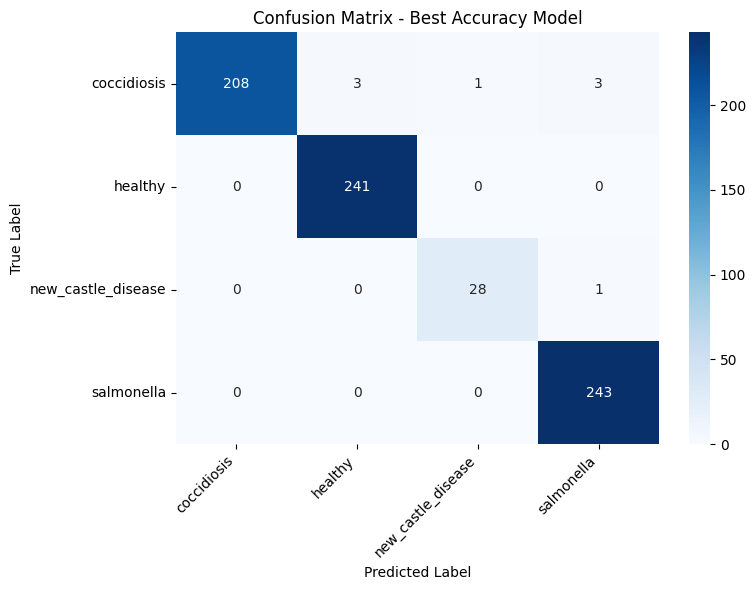

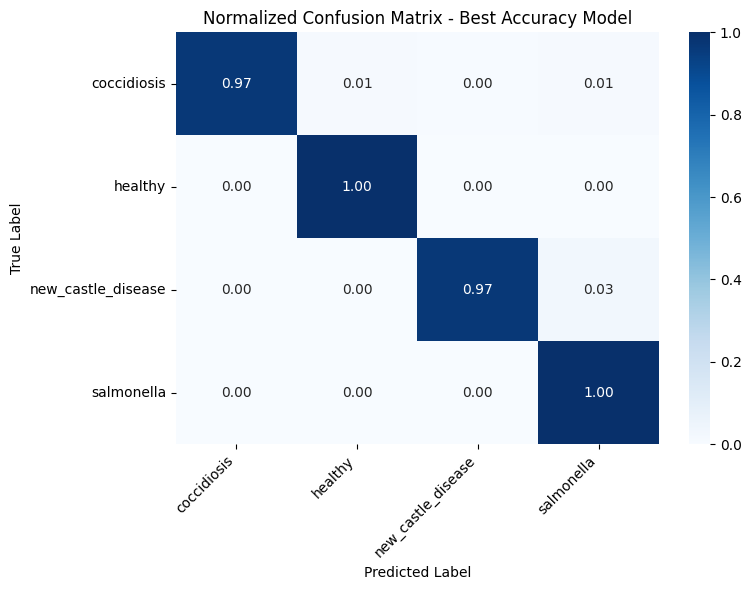

In [53]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# =========================
# LOAD BEST ACC MODEL
# =========================
best_acc_model = tf.keras.models.load_model(
    'best_multimodal_macro_ncd.h5',
    compile=False
)

# =========================
# PREDICTION
# =========================
best_acc_probs = best_acc_model.predict(
    [X_test_img_arr, X_test_txt_arr],
    verbose=0
)

best_acc_pred = np.argmax(best_acc_probs, axis=1)

# =========================
# OVERALL METRICS
# =========================
accuracy = accuracy_score(y_true, best_acc_pred)
precision_weighted = precision_score(y_true, best_acc_pred, average='weighted', zero_division=0)
recall_weighted = recall_score(y_true, best_acc_pred, average='weighted', zero_division=0)
f1_weighted = f1_score(y_true, best_acc_pred, average='weighted', zero_division=0)

precision_macro = precision_score(y_true, best_acc_pred, average='macro', zero_division=0)
recall_macro = recall_score(y_true, best_acc_pred, average='macro', zero_division=0)
f1_macro = f1_score(y_true, best_acc_pred, average='macro', zero_division=0)

eval_df = pd.DataFrame({
    'Metric': [
        'Accuracy',
        'Weighted Precision',
        'Weighted Recall',
        'Weighted F1',
        'Macro Precision',
        'Macro Recall',
        'Macro F1'
    ],
    'Score': [
        accuracy,
        precision_weighted,
        recall_weighted,
        f1_weighted,
        precision_macro,
        recall_macro,
        f1_macro
    ]
})

print("=== EVALUATION SUMMARY - BEST ACC MODEL ===")
print(eval_df)

# =========================
# CLASSIFICATION REPORT
# =========================
print("\n=== CLASSIFICATION REPORT - BEST ACC MODEL ===")
print(classification_report(
    y_true,
    best_acc_pred,
    target_names=le.classes_,
    zero_division=0
))

# =========================
# CONFUSION MATRIX
# =========================
cm = confusion_matrix(y_true, best_acc_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.title('Confusion Matrix - Best Accuracy Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# =========================
# NORMALIZED CONFUSION MATRIX
# =========================
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.title('Normalized Confusion Matrix - Best Accuracy Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()